# Test Angular Spectrum Fix

Compare old (ray tracing) vs new (Fraunhofer) formula for angular spectrum method.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo.angular_spectrum_fixed import AngularSpectrumSimulatorFixed
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.5)

import os
output_dir = '../data/angular_spectrum_fix_test'
os.makedirs(output_dir, exist_ok=True)

## Setup Parameters

In [2]:
# Simulation parameters
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
numerical_aperture = 0.1
n_medium = 1.0
random_seed = 42
fft_size = 2048

airy_radius = 1.22 * wavelength / numerical_aperture

print(f"N photons: {n_photons:,}")
print(f"Wavelength: {wavelength} μm")
print(f"NA: {numerical_aperture}")
print(f"Focal length: {focal_length} mm")
print(f"FFT size: {fft_size}")
print(f"First Airy zero: {airy_radius:.4f} μm")

N photons: 1,000,000
Wavelength: 0.6328 μm
NA: 0.1
Focal length: 10.0 mm
FFT size: 2048
First Airy zero: 7.7202 μm


## Run Both Simulators

In [3]:
print("Running OLD angular spectrum (ray tracing)...")
sim_old = AngularSpectrumSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    n_medium=n_medium,
    random_seed=random_seed,
    fft_size=fft_size
)
results_old = sim_old.propagate()
x_old, y_old, _ = results_old['focal_positions']
print(f"  Got {len(x_old):,} photons")

print("\nRunning FIXED angular spectrum (Fraunhofer)...")
sim_new = AngularSpectrumSimulatorFixed(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    n_medium=n_medium,
    random_seed=random_seed,
    fft_size=fft_size
)
results_new = sim_new.propagate()
x_new, y_new, _ = results_new['focal_positions']
print(f"  Got {len(x_new):,} photons")

Running OLD angular spectrum (ray tracing)...


  Got 999,998 photons

Running FIXED angular spectrum (Fraunhofer)...


  Got 1,000,000 photons


## Compute Theoretical Airy Pattern

In [4]:
# Radial bins
plot_range = 2 * airy_radius
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theoretical Airy pattern
k_theory = 2 * np.pi * numerical_aperture / wavelength
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

print(f"Theoretical Airy FWHM: {1.22 * wavelength / numerical_aperture:.4f} μm (approx)")

Theoretical Airy FWHM: 7.7202 μm (approx)


## Compute Radial Profiles

In [5]:
# OLD method
r_old = np.sqrt(x_old**2 + y_old**2)
hist_old, _ = np.histogram(r_old, bins=r_bins)
intensity_old = hist_old / bin_areas
intensity_old = intensity_old / np.max(intensity_old)

# NEW method
r_new = np.sqrt(x_new**2 + y_new**2)
hist_new, _ = np.histogram(r_new, bins=r_bins)
intensity_new = hist_new / bin_areas
intensity_new = intensity_new / np.max(intensity_new)

# Compute RMSE
rmse_old = metrics.rmse(intensity_old, airy_theory)
rmse_new = metrics.rmse(intensity_new, airy_theory)

print(f"\nRMSE Comparison:")
print(f"  OLD (ray tracing):  {rmse_old:.6f}")
print(f"  NEW (Fraunhofer):   {rmse_new:.6f}")
print(f"  Improvement: {(rmse_old - rmse_new) / rmse_old * 100:.1f}%")


RMSE Comparison:
  OLD (ray tracing):  0.031340
  NEW (Fraunhofer):   0.028399
  Improvement: 9.4%


## Plot Comparison

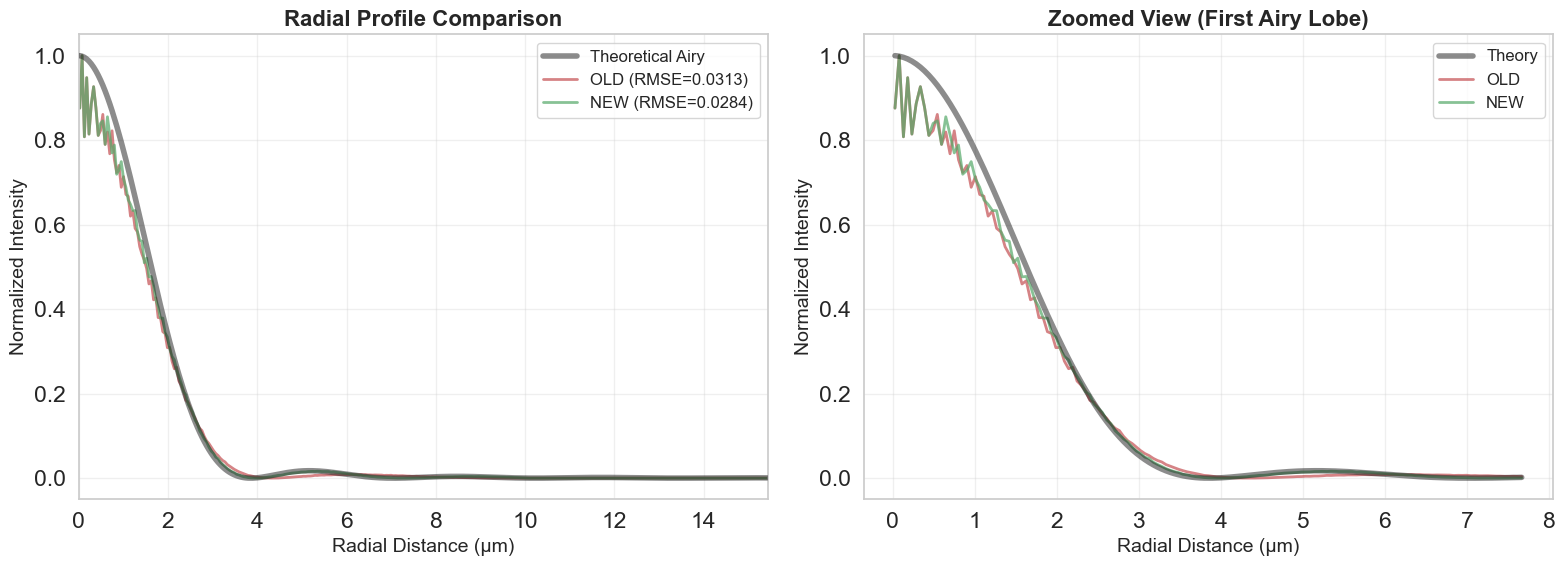

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Radial profiles
ax = axes[0]
ax.plot(r_centers, airy_theory, 'k-', linewidth=4, alpha=0.5, label='Theoretical Airy', zorder=10)
ax.plot(r_centers, intensity_old, 'r-', linewidth=2, alpha=0.7, label=f'OLD (RMSE={rmse_old:.4f})')
ax.plot(r_centers, intensity_new, 'g-', linewidth=2, alpha=0.7, label=f'NEW (RMSE={rmse_new:.4f})')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Radial Profile Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])

# Right: Zoomed comparison
ax = axes[1]
zoom_range = airy_radius
zoom_mask = r_centers < zoom_range
ax.plot(r_centers[zoom_mask], airy_theory[zoom_mask], 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers[zoom_mask], intensity_old[zoom_mask], 'r-', linewidth=2, alpha=0.7, label='OLD')
ax.plot(r_centers[zoom_mask], intensity_new[zoom_mask], 'g-', linewidth=2, alpha=0.7, label='NEW')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Zoomed View (First Airy Lobe)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Statistics

In [7]:
print("="*80)
print("COMPARISON: OLD vs NEW Angular Spectrum")
print("="*80)
print(f"\nOLD Method (Ray Tracing: x = f × kx/kz):")
print(f"  RMSE:     {rmse_old:.6f}")
print(f"  Mean r:   {np.mean(r_old):.6f} μm")
print(f"  Std r:    {np.std(r_old):.6f} μm")
print(f"  Max r:    {np.max(r_old):.6f} μm")

print(f"\nNEW Method (Fraunhofer: x = λf/(2π) × kx):")
print(f"  RMSE:     {rmse_new:.6f}")
print(f"  Mean r:   {np.mean(r_new):.6f} μm")
print(f"  Std r:    {np.std(r_new):.6f} μm")
print(f"  Max r:    {np.max(r_new):.6f} μm")

improvement = (rmse_old - rmse_new) / rmse_old * 100
print(f"\n{'='*80}")
print(f"IMPROVEMENT: {improvement:.1f}% reduction in RMSE")
print(f"{'='*80}")

COMPARISON: OLD vs NEW Angular Spectrum

OLD Method (Ray Tracing: x = f × kx/kz):
  RMSE:     0.031340
  Mean r:   2.672345 μm
  Std r:    5.341274 μm
  Max r:    845.095092 μm

NEW Method (Fraunhofer: x = λf/(2π) × kx):
  RMSE:     0.028399
  Mean r:   2.111645 μm
  Std r:    1.752586 μm
  Max r:    9.999700 μm

IMPROVEMENT: 9.4% reduction in RMSE
